In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.linalg import eig

In [2]:
m1 = 150.       # kg, massa sistema
k1 = 2.65e6     # Nm, rigidesa sistema

A0 = np.array([[0, 1],
               [-k1/m1, 0]])
B0 = np.array([[0],
               [1/m1]])
C0 = np.array([[1, 0]])
D0 = np.array([[0]])

sys0 = signal.StateSpace(A0, B0, C0, D0)

In [3]:
m2 = 25.    # kg, massa absorvidor

mu = m2 / m1
q_opt = 1 / (1 + mu)
zeta_opt = np.sqrt(3 * mu / (8 * (1 + mu)))

k2 = q_opt**2 * k1 * mu
c = zeta_opt * 2 * np.sqrt(k2 * m2)

A = np.array([
    [0, 1, 0, 0],
    [-(k1 + k2)/m1, -c/m1, k2/m1, c/m1],
    [0, 0, 0, 1],
    [k2/m2, c/m2, -k2/m2, -c/m2]
])

B = np.array([[0], [1/m1], [0], [0]])
C = np.array([[1, 0, 0, 0]])
D = np.array([[0]])

sys = signal.StateSpace(A, B, C, D)

In [4]:
w = np.linspace(20, 200, 5000)

def freq_response(A, B, C, D, w):
    H = []
    for wi in w:
        jwI_A = 1j * wi * np.eye(A.shape[0]) - A
        G = C @ np.linalg.inv(jwI_A) @ B + D
        H.append(G[0, 0])
    return np.array(H)

H0 = freq_response(A0, B0, C0, D0, w) * k1
H  = freq_response(A, B, C, D, w) * k1

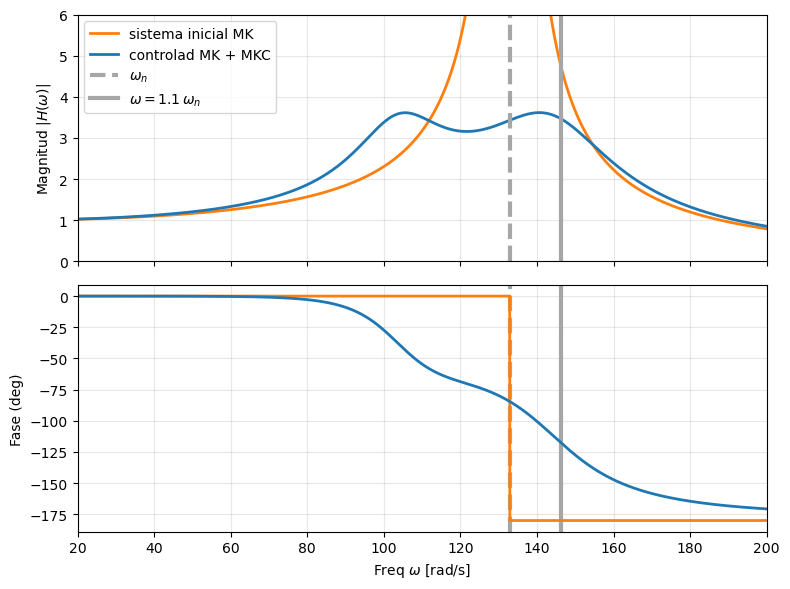

In [5]:
eigvals0 = eig(A0)[0]
eigvals  = eig(A)[0]

omega_n0 = np.abs(eigvals0)
omega_n  = np.abs(eigvals)

omega_exc = omega_n0[0] * 1.10

# càlcul fase (amb unwrap)
phase0 = np.unwrap(np.angle(H0))
phase  = np.unwrap(np.angle(H))

phase0_deg = np.degrees(phase0) * -1
phase_deg  = np.degrees(phase)

# figura amb 2 subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

# --- Magnitud ---
ax1.plot(w, np.abs(H0), color='tab:orange',  linewidth=2, label='sistema inicial MK')
ax1.plot(w, np.abs(H),  color='tab:blue',  linewidth=2,  label='controlad MK + MKC')

ax1.axvline(x=omega_n0[0], color='0.65', linestyle='--', linewidth=3, label=r'$\omega_n$')
ax1.axvline(x=omega_exc,  color='0.65', linestyle='-',  linewidth=3, label=r'$\omega = 1.1\,\omega_n$')

ax1.set_ylabel(r'Magnitud $|H(\omega)|$')
ax1.set_ylim([0, 6])
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- Fase ---
ax2.axvline(x=omega_n0[0], color='0.65', linestyle='--', linewidth=3)
ax2.axvline(x=omega_exc,  color='0.65', linestyle='-',  linewidth=3)
ax2.plot(w, phase0_deg, color='tab:orange', linewidth=2,)
ax2.plot(w, phase_deg,  color='tab:blue', linewidth=2,)


ax2.set_xlabel(r'Freq $\omega$ [rad/s]')
ax2.set_ylabel('Fase (deg)')
ax2.grid(True, alpha=0.3)

# límits comuns
ax2.set_xlim([20, 200])

plt.tight_layout()

In [6]:
def damping_from_poles(poles):
    wn = np.abs(poles)
    zeta = -np.real(poles) / wn
    return wn, zeta

wn, zeta_c = damping_from_poles(eigvals)

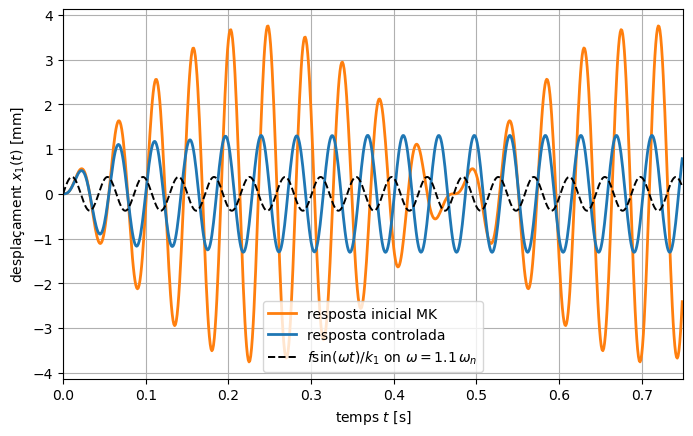

In [7]:
t = np.arange(0, 0.75, 0.001)
F0 = 1000

f = F0 * np.sin(omega_exc * t)

tout0, y0, _ = signal.lsim(sys0, U=f, T=t)
tout, y, _   = signal.lsim(sys,  U=f, T=t)

plt.figure(figsize=(8, 4.8))
plt.plot(t, y0 * 1e3, color='tab:orange',  linewidth=2, label='resposta inicial MK')
plt.plot(t, y  * 1e3, color='tab:blue', linewidth=2, label='resposta controlada')
plt.plot(t, (f / k1) * 1e3, '--', color='black', linewidth=1.4, label=r'$f \sin (\omega t)/k_1$ on $\omega = 1.1\,\omega_n$')
plt.xlim([0, 0.75])

plt.xlabel(r'temps $t$ [s]')
plt.ylabel(r'desplaçament $x_1(t)$ [mm]')
plt.legend()
plt.grid()

plt.show()